# Bài 07: Trực Quan Hóa Dữ Liệu - Data Visualization (Thảm Họa Titanic)
### Giới thiệu:
Trực quan hóa dữ liệu (Data Visualization) là kỹ năng biến các con số khô khan thành hình ảnh, biểu đồ trực quan, giúp nhà phân tích và các bên liên quan nhanh chóng nắm bắt xu hướng, mô hình và các điểm bất thường (Outliers):
- Làm quen với hai thư viện trực quan hóa mạnh mẽ nhất của Python: **Matplotlib** (nền tảng) và **Seaborn** (thống kê thẩm mỹ cao).
- Thiết lập cột định danh làm chỉ số bằng .set_index().
- Vẽ biểu đồ tròn (**Pie Chart**) thể hiện cơ cấu tỷ lệ thành phần.
- Vẽ biểu đồ phân tán (**Scatter Plot**) khảo sát mối quan hệ giữa 2 biến số liên tục (Tuổi vs Giá vé) kết hợp phân màu theo biến định tính (Giới tính).
- Vẽ biểu đồ tần số (**Histogram**) để khảo sát phân phối của biến số tiền vé.
- Trực quan hóa tỷ lệ sống sót theo hạng vé (**Bar Chart**).


### Step 1. Import các thư viện cần thiết (Pandas, Numpy, Matplotlib, Seaborn)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách hiển thị biểu đồ
sns.set_theme(style='whitegrid')
%matplotlib inline

### Step 2 & 3. Đọc dữ liệu từ URL và gán vào biến titanic

In [2]:
url = 'https://raw.githubusercontent.com/thieu1995/csv-files/main/data/pandas/titanic_train.csv'
titanic = pd.read_csv(url)
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Step 4. Đặt cột PassengerId làm chỉ số (Index) của DataFrame

In [3]:
titanic.set_index('PassengerId', inplace=True)
titanic.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Step 5. Tạo biểu đồ tròn (Pie Chart) thể hiện tỷ lệ Nam / Nữ

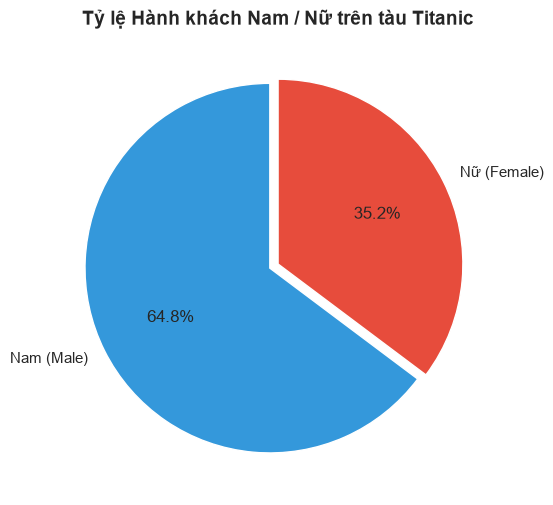

In [4]:
gender_counts = titanic['Sex'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=['Nam (Male)', 'Nữ (Female)'], autopct='%1.1f%%', 
        colors=['#3498db', '#e74c3c'], startangle=90, explode=(0.05, 0))
plt.title('Tỷ lệ Hành khách Nam / Nữ trên tàu Titanic', fontsize=14, fontweight='bold')
plt.show()

### Step 6. Tạo biểu đồ phân tán (Scatterplot) giữa Giá vé (Fare) và Tuổi (Age), phân biệt màu sắc theo Giới tính (Sex)

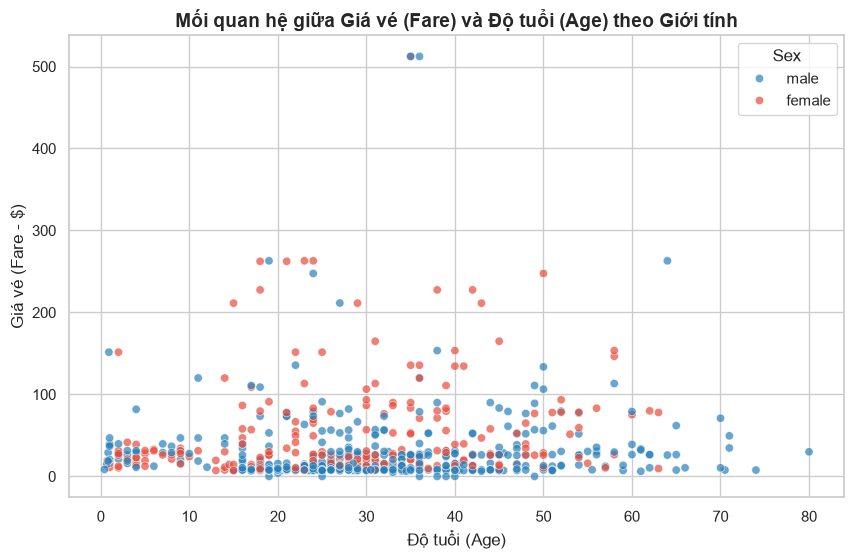

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=titanic, x='Age', y='Fare', hue='Sex', palette={'male': '#2980b9', 'female': '#e74c3c'}, alpha=0.7)
plt.title('Mối quan hệ giữa Giá vé (Fare) và Độ tuổi (Age) theo Giới tính', fontsize=14, fontweight='bold')
plt.xlabel('Độ tuổi (Age)', fontsize=12)
plt.ylabel('Giá vé (Fare - $)', fontsize=12)
plt.show()

### Step 7. Có bao nhiêu người đã sống sót sau thảm họa?

In [6]:
survived_count = titanic['Survived'].sum()
total_passengers = len(titanic)
survival_rate = (survived_count / total_passengers) * 100
print(f'Tổng số người sống sót: {survived_count} / {total_passengers} ({survival_rate:.2f}%)')

Tổng số người sống sót: 342 / 891 (38.38%)


### Step 8. Tạo biểu đồ tần số (Histogram) thể hiện phân phối của Giá vé (Fare)

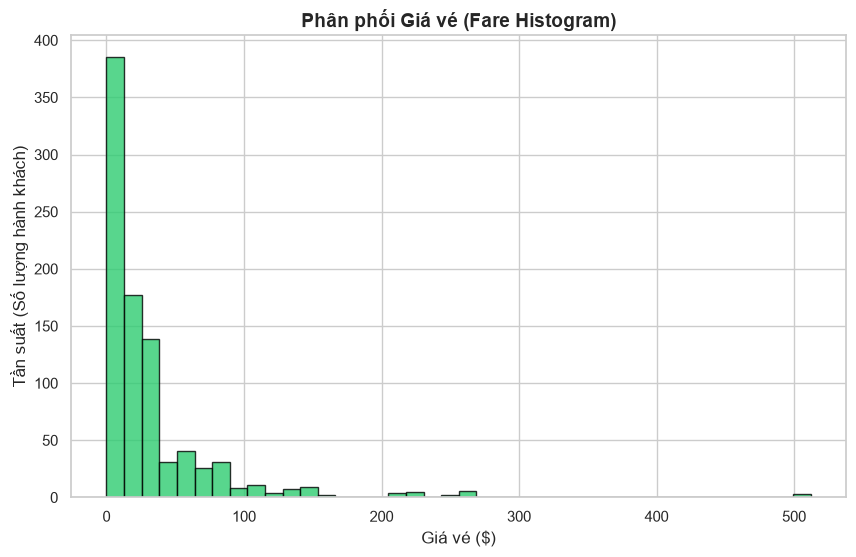

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(titanic['Fare'], bins=40, color='#2ecc71', edgecolor='black', alpha=0.8)
plt.title('Phân phối Giá vé (Fare Histogram)', fontsize=14, fontweight='bold')
plt.xlabel('Giá vé ($)', fontsize=12)
plt.ylabel('Tần suất (Số lượng hành khách)', fontsize=12)
plt.show()

### BONUS: Tỷ lệ sống sót theo Hạng vé (Pclass: 1st, 2nd, 3rd)

C:\Users\pc\AppData\Local\Temp\ipykernel_14180\1100484004.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=pclass_survival.index, y=pclass_survival.values, palette='Blues_d')


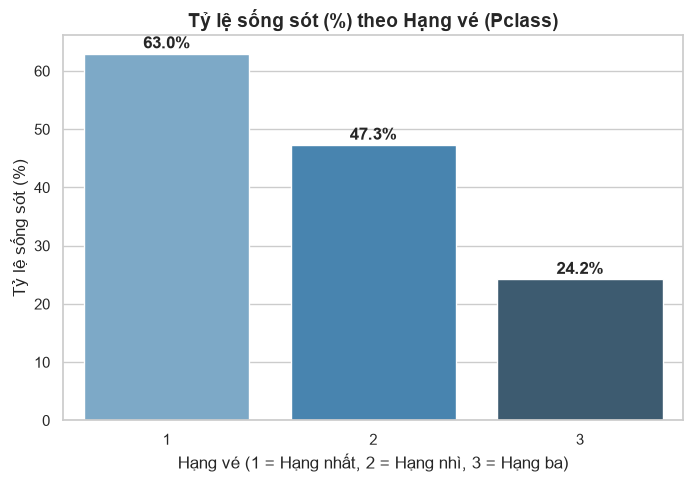

In [8]:
plt.figure(figsize=(8, 5))
pclass_survival = titanic.groupby('Pclass')['Survived'].mean() * 100
ax = sns.barplot(x=pclass_survival.index, y=pclass_survival.values, palette='Blues_d')
plt.title('Tỷ lệ sống sót (%) theo Hạng vé (Pclass)', fontsize=14, fontweight='bold')
plt.xlabel('Hạng vé (1 = Hạng nhất, 2 = Hạng nhì, 3 = Hạng ba)', fontsize=12)
plt.ylabel('Tỷ lệ sống sót (%)', fontsize=12)

# Hiển thị số liệu lên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontweight='bold')

plt.show()